# Data audit and management evidence

## tl;dr

This notebook reads the prepared SQLite model and generated evidence rather than repeating the cleaning pipeline. It shows the analytical population, daily availability exposure, category priorities, and product sales concentration. All amounts are **normalized sales units**, not currency or disclosed physical quantities.

The source has real stockout flags but no inventory balances, supplier records, or purchase orders. A risk queue identifies what to investigate; it does not establish actual order quantities.

Validation: all 11 Python cells ran sequentially in the project environment via cell extraction. Tables and figure definitions are saved. This is not a Jupyter-kernel execution claim. All three rendered charts were inspected for readable labels and saved with static image fallbacks for GitHub. The database population and reported risk counts reconcile with the generated evidence.

## Context & Methods

The operational grain is one **store-product-date**. The database may contain the complete public source or a stratified demonstration sample, depending on the reproducible pipeline arguments. Every chart reports the database population, while the separate quality evidence profiles the complete downloaded source.

### Key Assumptions

- Stockout exposure uses the 16 hourly bins **06:00–21:59**; zero sales alone do not establish a stockout.
- Product contribution shares are comparable because the publisher applies global sales normalization. They are not financial ABC.
- The latest date is the historical dataset end, not today's operations.
- Category labels remain encoded IDs. Observational comparisons are not causal findings.

Reproduce first with the README setup and preparation instructions. From a Jupyter environment with the project's dependencies installed, open this notebook and Run All. If needed, install Jupyter separately with `python -m pip install notebook`; Jupyter is optional for the dashboard.

Source: [Dingdong-Inc/FreshRetailNet-50K](https://huggingface.co/datasets/Dingdong-Inc/FreshRetailNet-50K), CC BY 4.0. Definitions and forecast protocol: [methodology](../docs/methodology.md).

In [1]:
import json
import sqlite3
from pathlib import Path

import pandas as pd
import plotly.express as px

root_candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next(
    (
        candidate
        for candidate in root_candidates
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "scdi").is_dir()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Open the notebook from this repository or its notebooks folder.")
DB_PATH = ROOT / "data" / "processed" / "decision_intelligence.sqlite"
if not DB_PATH.exists():
    DB_PATH = ROOT / "data" / "demo" / "decision_intelligence.sqlite"
if not DB_PATH.exists():
    raise FileNotFoundError(
        "Run the README data preparation steps to create the analytical database."
    )
connection = sqlite3.connect(DB_PATH.as_uri() + "?mode=ro", uri=True)
connection.execute("PRAGMA temp_store=MEMORY")
px.defaults.template = "plotly_white"
px.defaults.color_discrete_sequence = ["#246B8E", "#C65D3A", "#70958C", "#8B759C"]
{"database": str(DB_PATH.relative_to(ROOT)), "access": "read only"}

{'database': 'data/processed/decision_intelligence.sqlite', 'access': 'read only'}

## Data

### 1. Verify the analytical population

This query checks the prepared fact table rather than assuming that the dashboard uses the full public source. Distinct store-product series prevent double counting a product sold in several stores.

In [2]:
population = pd.read_sql_query(
    """
SELECT COUNT(*) AS rows, COUNT(DISTINCT series_id) AS store_product_series,
       COUNT(DISTINCT product_id) AS products, COUNT(DISTINCT store_id) AS stores,
       COUNT(DISTINCT city_id) AS cities, COUNT(DISTINCT category_id) AS category_ids,
       MIN(date) AS first_date, MAX(date) AS last_date,
       COUNT(DISTINCT date) AS observed_calendar_days,
       SUM(CASE WHEN stockout_hours > 0 THEN 1 ELSE 0 END) AS stockout_days,
       SUM(stockout_hours) AS stockout_hours,
       SUM(stockout_hours) / (16.0 * COUNT(*)) AS stockout_hour_rate
FROM daily_sales
""",
    connection,
)
assert population.loc[0, "rows"] == (
    population.loc[0, "store_product_series"] * population.loc[0, "observed_calendar_days"]
)
assert connection.execute("PRAGMA integrity_check").fetchone()[0] == "ok"
assert not connection.execute("PRAGMA foreign_key_check").fetchall()
population.round(4)

rows,store_product_series,products,stores,cities,category_ids,first_date,last_date,observed_calendar_days,stockout_days,stockout_hours,stockout_hour_rate
4850000,50000,865,898,18,32,2024-03-28,2024-07-02,97,2135444,15325567,0.1975


### 2. Read the full-source audit and schema

The JSON report is created by the pipeline. This notebook does not silently clean invalid records, impute missing periods, or cap unusual sales. The source audit must be distinguished from a smaller demonstration database population.

In [3]:
quality_path = ROOT / "docs" / "evidence" / "data_quality.json"
quality = json.loads(quality_path.read_text()) if quality_path.exists() else {}
# Full-source audit summary: top-level scalars are separate from nested raw-file profiles.
quality_summary = pd.DataFrame(
    [
        {"audit_field": key, "value": value}
        for key, value in quality.items()
        if isinstance(value, (str, int, float, bool))
    ]
)
quality_summary

audit_field,value
rows,4850000
source_columns,19
series,50000
stores,898
products,865
cities,18
categories,32
date_min,2024-03-28
date_max,2024-07-02
days_per_series,97


In [4]:
schema = pd.read_sql_query("PRAGMA table_info(fact_daily_sales)", connection)
schema[["name", "type", "notnull", "pk"]]

name,type,notnull,pk
series_id,TEXT,1,1
date,TEXT,1,2
sales,REAL,1,0
stockout_hours,INTEGER,1,0
discount,REAL,1,0
holiday_flag,INTEGER,1,0
activity_flag,INTEGER,1,0
source_split,TEXT,1,0


## Results

### 3. When is availability exposure highest?

Daily sales and stockout exposure use the same analytical population and historical dates. Stockout exposure is a ratio of observed unavailable hours to eligible operating hours. A sales decline is not itself evidence that unconstrained demand declined.

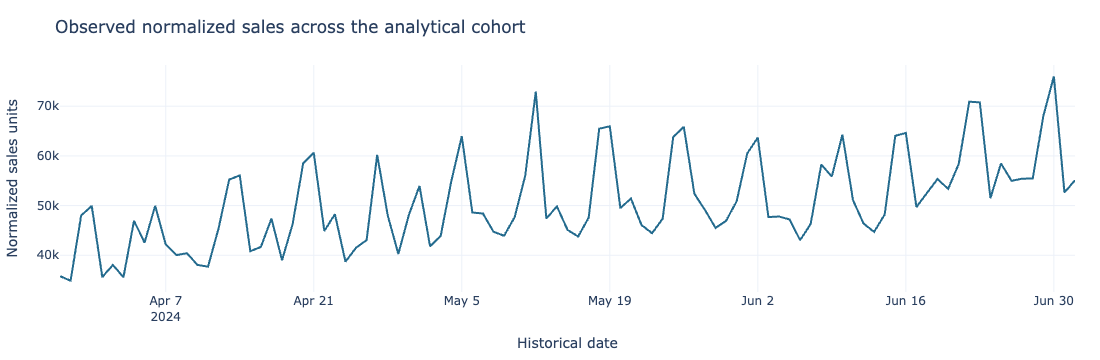

In [5]:
daily = pd.read_sql_query(
    """
SELECT date, SUM(sales) AS normalized_sales,
       SUM(stockout_hours) / (16.0 * COUNT(*)) AS stockout_hour_rate,
       COUNT(*) AS store_product_days
FROM daily_sales GROUP BY date ORDER BY date
""",
    connection,
)
fig_demand = px.line(
    daily,
    x="date",
    y="normalized_sales",
    title="Observed normalized sales across the analytical cohort",
    labels={"date": "Historical date", "normalized_sales": "Normalized sales units"},
)
fig_demand.update_layout(height=360, margin=dict(l=55, r=25, t=65, b=55))
fig_demand

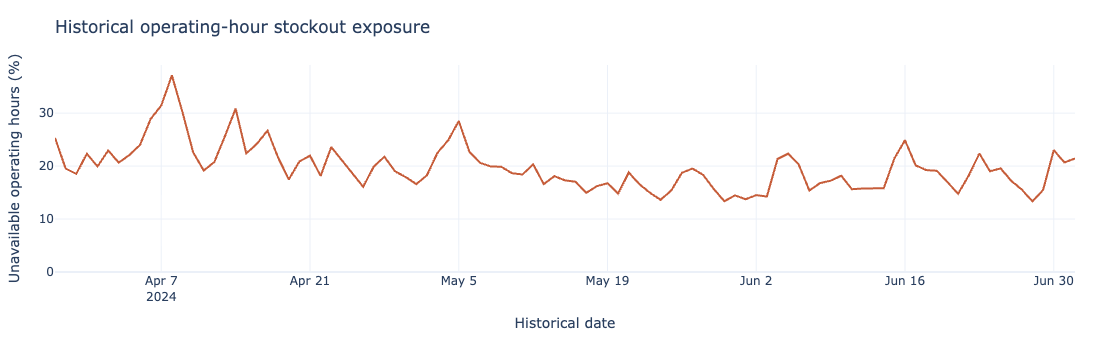

In [6]:
fig_availability = px.line(
    daily.assign(exposure_pct=daily.stockout_hour_rate * 100),
    x="date",
    y="exposure_pct",
    title="Historical operating-hour stockout exposure",
    labels={"date": "Historical date", "exposure_pct": "Unavailable operating hours (%)"},
)
fig_availability.update_traces(line_color="#C65D3A")
fig_availability.update_yaxes(rangemode="tozero")
fig_availability.update_layout(height=340, margin=dict(l=55, r=25, t=65, b=55))
fig_availability

### 4. Which encoded categories deserve review?

The SQL file keeps the business query visible in the repository. The rank is descriptive; product mix, store mix, and demand censoring can affect comparisons.

In [7]:
category_sql = (ROOT / "sql" / "01_category_availability.sql").read_text()
category = pd.read_sql_query(category_sql, connection)
category.head(12).round(4)

category_id,observed_days,store_product_series,stockout_day_rate,stockout_hour_rate,mean_normalized_sales
28,193806,1998,0.3891,0.2589,1.0516
29,339112,3496,0.6477,0.2561,1.4734
2,388,4,0.2990,0.2471,0.7652
10,275286,2838,0.3883,0.2187,0.7450
4,1056136,10888,0.4327,0.2032,1.1965
16,696169,7177,0.5075,0.1971,0.7343
20,536701,5533,0.4305,0.1954,1.3212
21,275771,2843,0.4626,0.1900,1.8582
0,35405,365,0.4891,0.1825,0.5145
12,3492,36,0.5123,0.1825,0.5552


### 5. How concentrated are observed product sales?

This curve aggregates a product across the stores included in the database. It answers a contribution question, not a shortage-location question. No product name or monetary value is inferred.

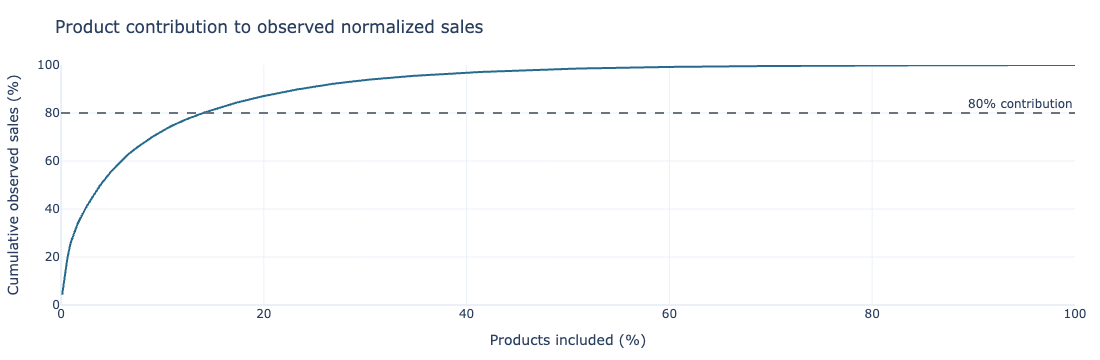

In [8]:
concentration_sql = (ROOT / "sql" / "03_product_concentration.sql").read_text()
concentration = pd.read_sql_query(concentration_sql, connection)
concentration["product_share_pct"] = 100 * concentration.sales_rank / len(concentration)
concentration["cumulative_sales_pct"] = 100 * concentration.cumulative_share
fig_concentration = px.line(
    concentration,
    x="product_share_pct",
    y="cumulative_sales_pct",
    title="Product contribution to observed normalized sales",
    labels={
        "product_share_pct": "Products included (%)",
        "cumulative_sales_pct": "Cumulative observed sales (%)",
    },
)
fig_concentration.add_hline(
    y=80, line_dash="dash", line_color="#6B7280", annotation_text="80% contribution"
)
fig_concentration.update_xaxes(range=[0, 100])
fig_concentration.update_yaxes(range=[0, 100])
fig_concentration.update_layout(height=360, margin=dict(l=55, r=25, t=65, b=55))
fig_concentration

### 6. Inspect the management queue

Risk combines the latest 28 days of stockout exposure with observed sales variability. ABC-style contribution classes use all 97 historical days. It does not use an assumed current inventory balance. Read the rule explanation in the methodology before interpreting an item as a purchasing instruction.

In [9]:
management_queue = pd.read_sql_query(
    """
SELECT series_id, store_id, product_id, category_id, availability_risk,
       stockout_hour_rate, stockout_day_fraction, sales_cv,
       volume_abc_class, xyz_class, priority_rank
FROM series_summary ORDER BY priority_rank LIMIT 12
""",
    connection,
)
management_queue.round(4)

series_id,store_id,product_id,category_id,availability_risk,stockout_hour_rate,stockout_day_fraction,sales_cv,volume_abc_class,xyz_class,priority_rank
359:90,359,90,4,Critical,0.9241,0.9643,2.7589,B,Z,1
4:129,4,129,10,Critical,0.8839,0.9643,2.1623,B,Z,2
519:151,519,151,31,Critical,0.8750,0.9286,0.2663,A,X,3
599:90,599,90,4,Critical,0.8638,0.9643,1.6793,B,Z,4
101:129,101,129,10,Critical,0.8594,0.8929,1.9474,B,Z,5
214:90,214,90,4,Critical,0.8549,0.9643,1.6558,A,Z,6
430:129,430,129,10,Critical,0.8527,0.9286,2.2940,B,Z,7
91:90,91,90,4,Critical,0.8504,0.9643,1.9942,C,Z,8
855:188,855,188,4,Critical,0.8438,0.9286,1.9328,C,Z,9
633:129,633,129,10,Critical,0.8415,0.9286,1.7443,B,Z,10


### 7. Read generated findings without hard-coded percentages

The evidence file is written from actual pipeline results. The subset displayed here contains scalar findings only; the complete file retains model metrics and other structured evidence.

In [10]:
findings_path = ROOT / "docs" / "evidence" / "findings.json"
findings = json.loads(findings_path.read_text()) if findings_path.exists() else {}


def scalar_evidence(value, prefix=""):
    rows = []
    for key, item in value.items():
        label = f"{prefix}.{key}" if prefix else key
        if isinstance(item, dict):
            rows.extend(scalar_evidence(item, label))
        elif isinstance(item, (str, int, float, bool)):
            rows.append({"finding": label, "value": item})
    return rows


# These full-source findings do not change when the notebook reads only the demo database.
evidence_selection = {
    key: findings.get(key, {}) for key in ("data", "risk_window", "product_concentration")
}
evidence_selection["holdout_all_days"] = (
    findings.get("forecast", {}).get("holdout_metrics", {}).get("all_days", {})
)
findings_summary = pd.DataFrame(scalar_evidence(evidence_selection))
findings_summary

finding,value
data.rows,4850000
data.series,50000
data.stores,898
data.products,865
data.cities,18
data.categories,32
data.date_min,2024-03-28
data.date_max,2024-07-02
data.days_per_series,97
data.stockout_days,2135444


## Takeaways

Management should investigate the highest-ranked **store-product** combinations, examine recurring unavailable hours, and compare the queue with actual inventory and replenishment records before acting. The contribution curve identifies where observed sales are concentrated, while the queue identifies where measured availability has been poor.

Short-horizon forecasts target observed sales and may underestimate latent demand under stockouts. Inventory scenarios require explicitly entered lead time, service targets, and inventory position; these are planning assumptions, not source-company facts. Supplier analysis and monetary inventory metrics are unavailable in this dataset.

In [11]:
connection.close()
"Read-only audit complete."

'Read-only audit complete.'